# **ETTh1 | Multi-to-Univariate_One-Shot Forecasting of OT**
---

In [7]:
# Package-specific imports
from utils.data_utils import data_import, data_prep
from utils.data_loader import create_batches
from utils.training import model_training
from utils.evaluation import model_test, prediction_plot
from models.lstm_model import LSTM_ForecastModel

# General imports
import torch
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd


#### **Setting Key Parameters**

In [8]:
# Hyperparameter definition w/o Optuna tuning -- can be added later
context_length  = 96       # [hours]
forecast_length = 96       # [hours]
batch_size      = 64       # [samples]
lstm_width      = 15
lstm_depth      = 1
optimizer_learningrate = 0.0001
max_epochs      = 100
patience_epochs = 15

----
## **INITIALIZATION**
----

#### **Importing the Dataset**

In [9]:
# Set link to original dataset
url_ETTh1 = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/refs/heads/main/ETT-small/ETTh1.csv"

# Import full data set from original source
ETTh1_data_df = data_import(url_ETTh1)

#### **Split, Scale, and Batch Data**
- Chosing the MinMaxScaler over the StandardScaler because it allows to bound all signals to a fixed interval of magnitudes: no channel shall introduce overfitting due to pure differences in magnitude --> feels "cleaner" for multivariate inputs.
- Choosing (-1,1) as interval for the MinMaxScaler for neutral signal processing
- Using the typical ETT 12 - 4 - 4 split, resulting in a total of 20 months of data
- The dataset contains almost 24 months, so the remaining c. 4 months get cut and are **discarded**
- Validation and test datasets are extended so that x_val and x_test start in the training and validation set already

In [10]:
# Set up the scaler
scaler = MinMaxScaler(feature_range=(-1, 1))

In [11]:
# Split and scale data
prepared_data = data_prep(
    source_data         = ETTh1_data_df,
    train_length_months = 12,
    vali_length_months  = 4,
    test_length_months  = 4,
    context_length      = context_length,
    scaler              = scaler
)

# Extract the dictionary containing the scalers for each input data channel
scalers_dict = prepared_data[3]

# Create samples and batches
batched_data = create_batches(
    prepared_data    = prepared_data,
    context_length   = context_length,
    forecast_length  = forecast_length,
    batch_size       = batch_size,
    training_shuffle = True
)

Timesteps in the source dataset:  17420 hours
Timesteps in the truncated split:  14400 hours
Timesteps in the training split:  8640 hours
Timesteps in the discarded split:  3020 hours
The training/validation/test split relative to the truncated set [%]:  60.0 / 20.0 / 20.0
x_inputs batch shape: torch.Size([64, 96, 7])
y_targets batch shape: torch.Size([64, 96])
Number of batches: 133


In [12]:
# Initialize the model
model = LSTM_ForecastModel(
    num_input_features = ETTh1_data_df.shape[1],  # columns in the input dataframe
    lstm_width         = lstm_width,
    lstm_depth         = lstm_depth,
    forecast_length    = forecast_length
)

# Print number of trainable parameters
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model has {num_params} trainable parameters.")


Model has 2976 trainable parameters.


----
## **TRAINING**
----

- for a clean re-training run with default parameters and random seeds, re-initialize the model above

Device: cpu
Epoch:   1 | Train loss: 0.03012195 | Val loss: 0.03930774
Epoch:   2 | Train loss: 0.02801315 | Val loss: 0.03735795
Epoch:   3 | Train loss: 0.02705197 | Val loss: 0.03440977
Epoch:   4 | Train loss: 0.02619110 | Val loss: 0.03204421
Epoch:   5 | Train loss: 0.02569413 | Val loss: 0.02998325
Epoch:   6 | Train loss: 0.02521190 | Val loss: 0.02900863
Epoch:   7 | Train loss: 0.02492871 | Val loss: 0.02736434
Epoch:   8 | Train loss: 0.02494038 | Val loss: 0.02688612
Epoch:   9 | Train loss: 0.02447173 | Val loss: 0.02609282
Epoch:  10 | Train loss: 0.02444052 | Val loss: 0.02557460
Epoch:  11 | Train loss: 0.02400866 | Val loss: 0.02570540
Epoch:  12 | Train loss: 0.02386549 | Val loss: 0.02533742
Epoch:  13 | Train loss: 0.02388932 | Val loss: 0.02499292
Epoch:  14 | Train loss: 0.02368870 | Val loss: 0.02458421
Epoch:  15 | Train loss: 0.02353287 | Val loss: 0.02414518
Epoch:  16 | Train loss: 0.02347330 | Val loss: 0.02444211
Epoch:  17 | Train loss: 0.02341496 | Val lo

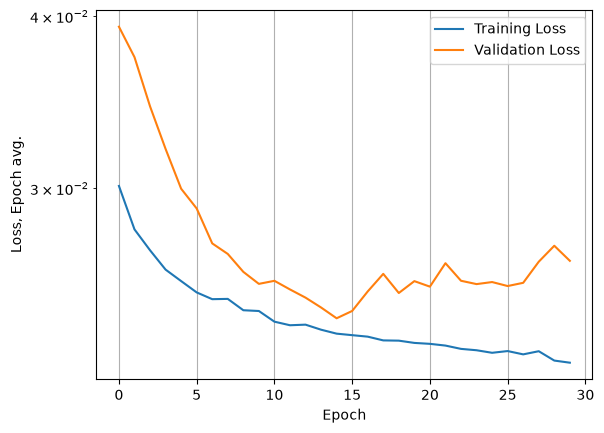

Best results are achieved for 15 training epochs.


In [8]:
# Run the training loop to find the best-performing internal states of the model
best_states_dict = model_training(
    model                  = model,
    data_batches           = batched_data,
    max_epochs             = max_epochs,
    patience_epochs        = patience_epochs,
    optimizer_learningrate = optimizer_learningrate
)

In [10]:
# Save the best model parameters
torch.save(model.state_dict(best_states_dict), "LSTM_1x15_weights.pt")

/tmp/ipykernel_16154/3013962488.py:2: FutureWarning: Positional args are being deprecated, use kwargs instead. Refer to https://pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.state_dict for details.
  torch.save(model.state_dict(best_states_dict), "LSTM_1x15_weights.pt")


----
## **TEST & EVALUATION**
----

In [13]:
# Optional loading of states dicts - avoiding retraining
loaded_states_dict = torch.load("LSTM_1x15_weights.pt")

In [14]:
# Run the test
test_results = model_test(
    model = model,
    best_state_dict = loaded_states_dict,
    data_batches = batched_data,
    scalers_dict = scalers_dict,
)

Device: cpu

Test MSE: 44.80453885
Test MAE: 6.23017112


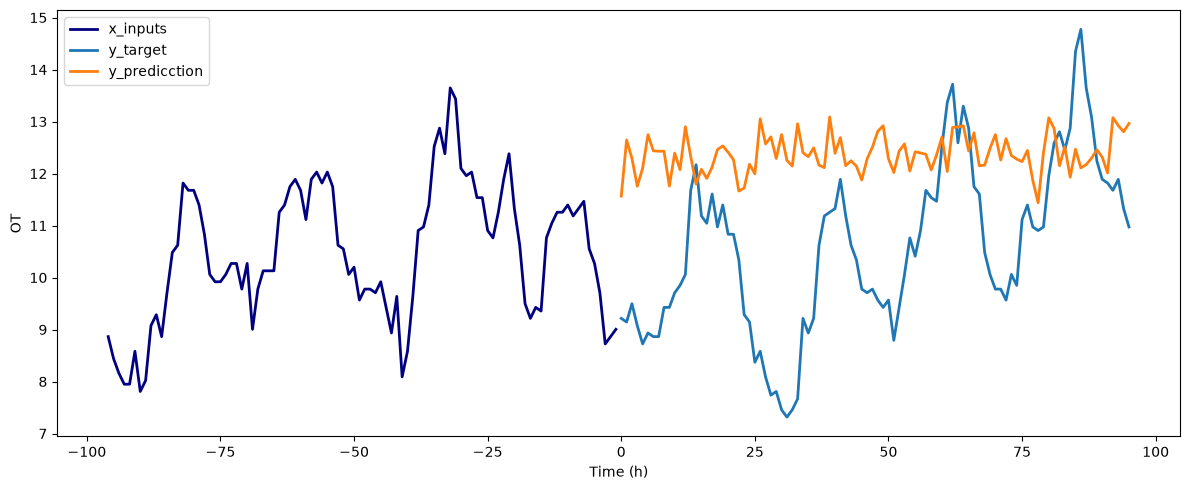

In [15]:
# Plot the results
prediction_plot(
    prepared_data   = prepared_data,
    test_results    = test_results,
    context_length  = context_length,
    forecast_length = forecast_length
)

### **Checking if the Predictions Make Sense**
- Mean of training split is significantly higher than the test split --> explains well why the prediction has a much higher mean, it's overfitted to the higher training mean:

In [33]:
# Retrieve data splits
training_set_scaled, _, _, _, training_split, validation_split, test_split = prepared_data 

# Unpack results
y_predictions, y_targets, _, _, y_predictions_batch_scaled, y_targets_batch_scaled = test_results       # remove last two after test

# Compare 
print(f"OT training split mean: {training_split["OT"].mean():.2f}")
print(f"OT validation split mean: {validation_split["OT"].mean():.2f}")
print(f"OT test split mean: {test_split["OT"].mean():.2f}")

print(f"Prediction mean, first prediction: {y_predictions[0].mean():.2f}")
print(f"Prediction mean, all predictions: {y_predictions.mean():.2f}")
print(f"Test target mean, first prediction: {y_targets[0].mean():.2f}")
print(f"Test target mean, all predictions: {y_targets.mean():.2f}")

OT training split mean: 17.13
OT validation split mean: 15.58
OT test split mean: 4.85
Prediction mean, first prediction: 12.37
Prediction mean, all predictions: 11.02
Test target mean, first prediction: 10.60
Test target mean, all predictions: 4.80


- Scaling works, the manual inverse transform cancels out with what the functions provide:

In [ ]:
ytp = scalers_dict["OT"].inverse_transform(y_predictions_batch_scaled)
print(ytp[0])

#must compare the very last prediction sample
print(ytp[-1]-y_predictions[-1])

[ 8.65630904  7.4176756   8.96725076  7.36127061  9.301834    8.87434083
  9.38514955  8.30969905  9.05246354  8.92080214  7.70067978  9.52520222
  9.14161782  9.97656829  8.53415172  9.02601722  8.96018054  8.50065533
  9.72715006  8.5195172   7.66209923  8.86275218  7.6254159   8.06000019
  8.45686373  8.48914953  8.62585106  8.59350929  9.10053101  9.63905337
  9.92695213  8.38817076  8.93163025  9.2039832   8.34990367  8.28907578
  9.04398346  8.68304794  8.84544198  9.14320159  8.66614152  8.91461486
  9.05550419  9.6895935   9.85738667  8.97764001  8.92309867  7.82989762
  8.32722644  8.41805927  9.66824105  8.49046908  9.92697676  9.38213278
  9.31072756  9.49665341  8.33713056 10.12440618  9.02233993 10.09129118
  9.06159967  8.53821636  9.38524508  9.64006542  9.27054831  8.25267607
  8.49098258  8.59710821  9.25999038  8.48922566  8.57842621  6.95451639
  8.81314349  9.49423597  8.85198452  9.06630245  8.88235369  8.55915534
  7.59217925  8.77325383 10.34926337 10.11777034  8

In [20]:
scalers_dict["OT"]

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(-1, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value
"data_max_ data_max_: ndarray of shape (n_features,)Per feature maximum seen in the data.. versionadded:: 0.17 *data_max_*","ndarray[float64](1,)",[46.01]
"data_min_ data_min_: ndarray of shape (n_features,)Per feature minimum seen in the data.. versionadded:: 0.17 *data_min_*","ndarray[float64](1,)",[-4.08]
"data_range_ data_range_: ndarray of shape (n_features,)Per feature range ``(data_max_ - data_min_)`` seen in the data.. versionadded:: 0.17 *data_range_*","ndarray[float64](1,)",[50.09]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['OT']
"min_ min_: ndarray of shape (n_features,)Per feature adjustment for minimum. Equivalent to``min - X.min(axis=0) * self.scale_``","ndarray[float64](1,)",[-0.84]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
"n_samples_seen_ n_samples_seen_: intThe number of samples processed by the estimator.It will be reset on new calls to fit, but increments across``partial_fit`` calls.",int,8640


In [21]:
scalers_dict["HULL"]

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(-1, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value
"data_max_ data_max_: ndarray of shape (n_features,)Per feature maximum seen in the data.. versionadded:: 0.17 *data_max_*","ndarray[float64](1,)",[8.84]
"data_min_ data_min_: ndarray of shape (n_features,)Per feature minimum seen in the data.. versionadded:: 0.17 *data_min_*","ndarray[float64](1,)",[-3.42]
"data_range_ data_range_: ndarray of shape (n_features,)Per feature range ``(data_max_ - data_min_)`` seen in the data.. versionadded:: 0.17 *data_range_*","ndarray[float64](1,)",[12.26]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['HULL']
"min_ min_: ndarray of shape (n_features,)Per feature adjustment for minimum. Equivalent to``min - X.min(axis=0) * self.scale_``","ndarray[float64](1,)",[-0.44]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
"n_samples_seen_ n_samples_seen_: intThe number of samples processed by the estimator.It will be reset on new calls to fit, but increments across``partial_fit`` calls.",int,8640


- model seems to just not capture deviations well, the scaling works:

In [40]:
#Standard deviations

print(f"OT training split standard deviation, first context window: {np.std(training_split["OT"].iloc[:context_length]):.2f}")
print(f"Test target standard deviation, first prediction: {np.std(y_targets[0]):.2f}")
print(f"Test prediction standard deviation, first prediction: {np.std(y_predictions[0]):.2f}")


OT training split standard deviation, first context window: 4.25
Test target standard deviation, first prediction: 1.61
Test prediction standard deviation, first prediction: 0.36
